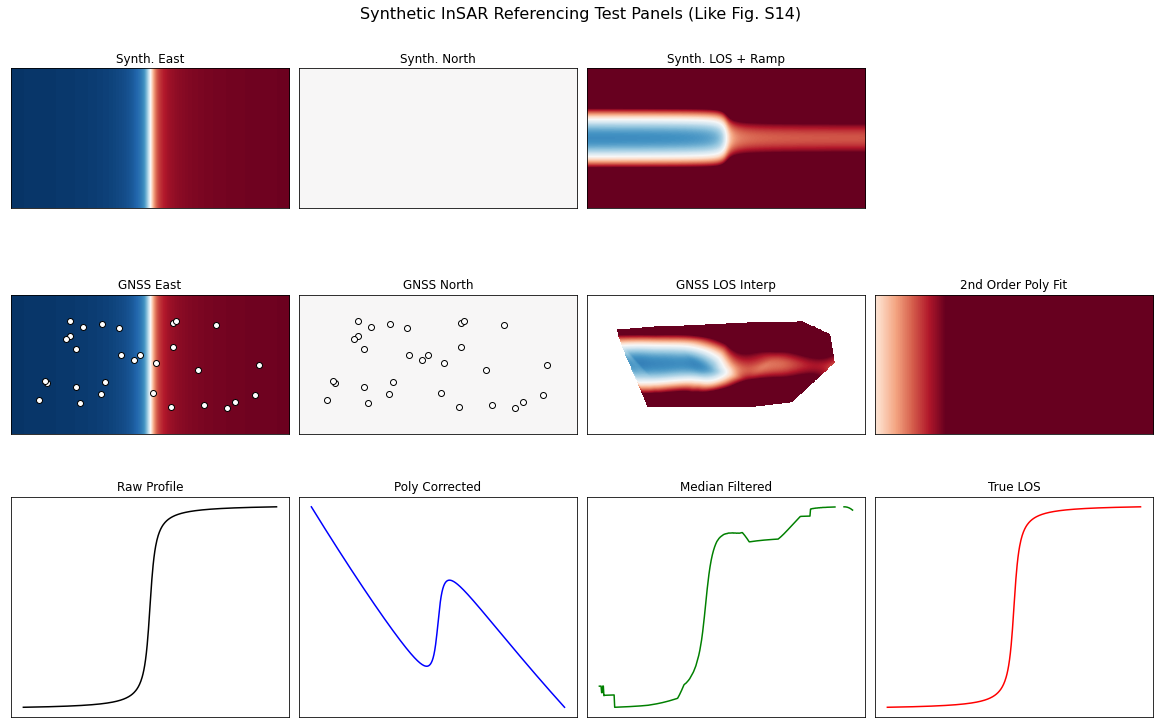

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter
from scipy.interpolate import griddata

# Set up the synthetic domain
x = np.linspace(-300, 300, 600)
y = np.linspace(-150, 150, 300)
X, Y = np.meshgrid(x, y)

# Define screw dislocation function
def screw_dislocation(x, s=10, d=10):
    return (s / np.pi) * np.arctan(x / d)

# Generate synthetic East and North velocities
east_vel = screw_dislocation(X, s=10, d=10)
north_vel = np.zeros_like(east_vel)

# Project into LOS with a ramp added
inc_angle = 40 * np.pi / 180
los_vel = east_vel * np.sin(inc_angle) + north_vel * np.cos(inc_angle)
los_ramp = 0.002 * (Y**2 - np.mean(Y)**2)
los_with_ramp = los_vel + los_ramp

# Generate synthetic GNSS stations
np.random.seed(42)
n_stations = 30
x_stn = np.random.uniform(-250, 250, n_stations)
y_stn = np.random.uniform(-100, 100, n_stations)
east_stn = screw_dislocation(x_stn, s=10, d=10)
north_stn = np.zeros_like(east_stn)
los_stn = east_stn * np.sin(inc_angle) + 0.002 * (y_stn**2 - np.mean(Y)**2)

# Interpolate GNSS LOS onto grid
points = np.column_stack((x_stn, y_stn))
los_stn_interp = griddata(points, los_stn, (X, Y), method='cubic', fill_value=np.nan)

# Polynomial fit
poly_coeff = np.polyfit(x_stn, los_stn, 2)
poly_fit = np.polyval(poly_coeff, X[0, :])
poly_surface = np.tile(poly_fit, (Y.shape[0], 1))

# Median filter residual referencing
residual = los_with_ramp - los_stn_interp
median_filtered = los_with_ramp - median_filter(residual, size=(1, 100))

# Set up plots like Figure S14
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
cmap = "RdBu_r"
vmin, vmax = -5, 5

# Row 1: Synthetic input
axes[0, 0].imshow(east_vel, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[0, 0].set_title("Synth. East")
axes[0, 1].imshow(north_vel, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[0, 1].set_title("Synth. North")
axes[0, 2].imshow(los_with_ramp, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[0, 2].set_title("Synth. LOS + Ramp")
axes[0, 3].axis("off")

# Row 2: GNSS sampled
axes[1, 0].imshow(east_vel, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[1, 0].scatter(x_stn, y_stn, c='white', edgecolor='black', label='GNSS')
axes[1, 0].set_title("GNSS East")
axes[1, 1].imshow(north_vel, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[1, 1].scatter(x_stn, y_stn, c='white', edgecolor='black')
axes[1, 1].set_title("GNSS North")
axes[1, 2].imshow(los_stn_interp, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[1, 2].set_title("GNSS LOS Interp")
axes[1, 3].imshow(poly_surface, extent=[-300, 300, -150, 150], cmap=cmap, vmin=vmin, vmax=vmax)
axes[1, 3].set_title("2nd Order Poly Fit")

# Row 3: Profiles
profile_idx = Y.shape[0] // 2
x_profile = x
raw = los_with_ramp[profile_idx, :]
poly_corrected = los_with_ramp[profile_idx, :] - poly_surface[profile_idx, :]
filtered = median_filtered[profile_idx, :]
true = los_vel[profile_idx, :]

axes[2, 0].plot(x_profile, raw, label="Raw LOS", color='black')
axes[2, 0].set_title("Raw Profile")
axes[2, 1].plot(x_profile, poly_corrected, label="Poly Corrected", color='blue')
axes[2, 1].set_title("Poly Corrected")
axes[2, 2].plot(x_profile, filtered, label="Median Filtered", color='green')
axes[2, 2].set_title("Median Filtered")
axes[2, 3].plot(x_profile, true, label="True LOS", color='red')
axes[2, 3].set_title("True LOS")

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Synthetic InSAR Referencing Test Panels (Like Fig. S14)", fontsize=16)
plt.show()
